✅ Dataset Loaded
Initial Shape: (625783, 86)
Cleaned Shape: (261543, 80)
Final Shape after filtering classes: (261543, 80)
✅ SMOTE Applied
✅ Top 20 MI Features Selected

📊 Model Performance (Top 20 MI Features)

🧠 Random Forest
Train Accuracy: 0.9995
Test Accuracy : 0.9625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11872
           1       0.74      0.85      0.79      3009
           2       0.98      0.96      0.97     28667
           3       0.99      0.98      0.99      5506
           4       0.86      0.90      0.88      3255

    accuracy                           0.96     52309
   macro avg       0.92      0.94      0.93     52309
weighted avg       0.96      0.96      0.96     52309

--------------------------------------------------
🧠 KNN
Train Accuracy: 0.9706
Test Accuracy : 0.9449
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11872
           1       0.62  

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.999505,0.962454,0.037051
MLP,0.803283,0.770537,0.032746
KNN,0.970551,0.944943,0.025608
XGBoost,0.969382,0.959510,0.009873


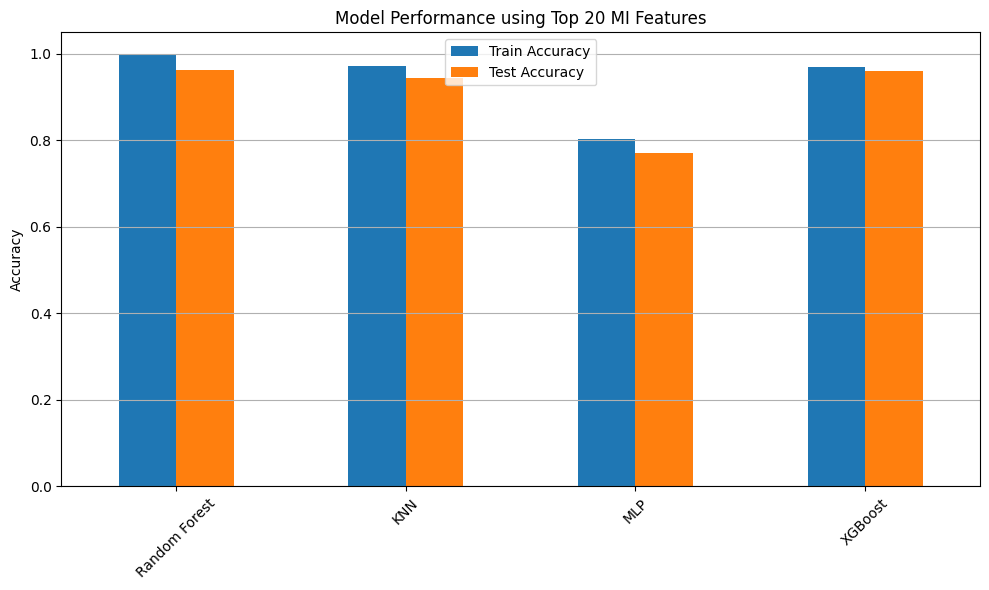

In [1]:
# ===============================
# 1. Suppress Warnings
# ===============================
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 2. Imports
# ===============================
import pandas as pd
import numpy as np

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ===============================
# 3. Load Dataset
# ===============================
df = pd.read_csv('/content/IoT Network Intrusion Dataset.csv')
print("✅ Dataset Loaded")
print(f"Initial Shape: {df.shape}")

# ===============================
# 4. Drop Unwanted Columns
# ===============================
drop_cols = ['Flow_ID', 'Src_IP', 'Dst_IP', 'Timestamp', 'Label', 'Sub_Cat']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# ===============================
# 5. Handle Missing & Infinite Values
# ===============================
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

print(f"Cleaned Shape: {df.shape}")

# ===============================
# 6. Encode Target
# ===============================
le = LabelEncoder()
df['Cat'] = le.fit_transform(df['Cat'])

X = df.drop('Cat', axis=1)
y = df['Cat']

# ===============================
# 7. Remove Minority Classes (<2 samples)
# ===============================
class_counts = y.value_counts()
minority_classes = class_counts[class_counts < 2].index

if len(minority_classes) > 0:
    df = df[~df['Cat'].isin(minority_classes)]
    le = LabelEncoder()
    df['Cat'] = le.fit_transform(df['Cat'])

X = df.drop('Cat', axis=1)
y = df['Cat']

print(f"Final Shape after filtering classes: {df.shape}")

# ===============================
# 8. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ===============================
# 9. Apply SMOTE (Training Only)
# ===============================
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ SMOTE Applied")

# ===============================
# 10. Mutual Information (Top 20 Features)
# ===============================
mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

TOP_K = 20
top_features = mi_series.head(TOP_K).index.tolist()

print(f"✅ Top {TOP_K} MI Features Selected")

X_train_mi = X_train_bal[top_features]
X_test_mi = X_test[top_features]

# ===============================
# 11. Models
# ===============================
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
}

# ===============================
# 12. Train & Evaluate
# ===============================
results = {}

print("\n📊 Model Performance (Top 20 MI Features)\n")

for name, model in models.items():
    model.fit(X_train_mi, y_train_bal)

    y_train_pred = model.predict(X_train_mi)
    y_test_pred = model.predict(X_test_mi)

    train_acc = accuracy_score(y_train_bal, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    }

    print(f"🧠 {name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(classification_report(y_test, y_test_pred))
    print("-" * 50)

# ===============================
# 13. Overfitting Analysis
# ===============================
results_df = pd.DataFrame(results).T
results_df["Gap"] = results_df["Train Accuracy"] - results_df["Test Accuracy"]

print("\n📉 Overfitting Check")
display(results_df.sort_values("Gap", ascending=False))

# ===============================
# 14. Visualization
# ===============================
results_df[['Train Accuracy', 'Test Accuracy']].plot(
    kind='bar', figsize=(10,6)
)
plt.title("Model Performance using Top 20 MI Features")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [10]:
from google.colab import files

print("Please upload your 'IoT Network Intrusion Dataset.csv' file.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    # The uploaded file will overwrite the existing one at '/content/IoT Network Intrusion Dataset.csv'
    with open('/content/IoT Network Intrusion Dataset.csv', 'wb') as f:
        f.write(uploaded[filename])
    print("File uploaded and replaced the existing one. Now re-run the main notebook cell (Tebcj-UALocy).")

Please upload your 'IoT Network Intrusion Dataset.csv' file.


Saving IoT Network Intrusion Dataset.csv to IoT Network Intrusion Dataset (1).csv
User uploaded file "IoT Network Intrusion Dataset (1).csv" with length 308528901 bytes
File uploaded and replaced the existing one. Now re-run the main notebook cell (Tebcj-UALocy).


After uploading the correct file using the cell above, you will need to re-run the main notebook cell (cell `Tebcj-UALocy`) for the changes to take effect and for the correct shape to be loaded.